# Batch Run Comparison

Compare results across all three scenario experiments:

- **Baseline** (`batch_baseline_20260528_231106`)
- **Conservative** (`batch_conservative_20260529_000355`)
- **Optimistic** (`batch_optimistic_20260529_005521`)

Figures produced:

1. Distribution of cumulative profit — three experiments in one figure.
2. BET fleet share — one subplot per experiment.
3. BET fleet share — all three experiments combined with side-by-side boxes.


## 1 — Import libraries


In [20]:
import pathlib

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fleet_replacement.episode import EpisodeRecord

REPO_ROOT = pathlib.Path.cwd().parent

sns.set_theme(style="whitegrid")

# PGF / LaTeX font settings (mirrors analyse_batch.ipynb)
matplotlib.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "pgf.rcfonts": False,  # use LaTeX's own font, not matplotlib's
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 10,
        "axes.labelsize": 7,
        "axes.titlesize": 8,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
    }
)

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures dir: {FIGURES_DIR}")

Figures dir: c:\git\KTH\fleet-replacement\figures


## 2 — Load batch run data

Load all `episode_*.pkl` files from each of the three result folders.


In [2]:
IMPORTANT_DIR = REPO_ROOT / "results" / "important"

# EXPERIMENTS = {
#     "Baseline": IMPORTANT_DIR / "batch_baseline_20260601_010719",
#     "Conservative": IMPORTANT_DIR / "batch_conservative_20260601_021136",
#     "Optimistic": IMPORTANT_DIR / "batch_optimistic_20260601_032927",
#     "Myopic": REPO_ROOT / "results" / "batch_env_myopic_20260608_150001",
# }
EXPERIMENTS = {
    "DLA: No-change": IMPORTANT_DIR
    / "2000"
    / "batch_env_lookahead_baseline_20260609_170434",
    "DLA: Low-progress": IMPORTANT_DIR
    / "2000"
    / "batch_env_lookahead_conservative_20260609_170433",
    "DLA: High-progress": IMPORTANT_DIR
    / "2000"
    / "batch_env_lookahead_optimistic_20260609_170433",
    "Myopic": IMPORTANT_DIR / "2000" / "batch_env_myopic_20260609_170434",
}

# Palette — one colour per experiment (used consistently in all figures)
PALETTE = {
    "DLA: No-change": "steelblue",
    "DLA: Low-progress": "darkorange",
    "DLA: High-progress": "seagreen",
    "Myopic": "mediumpurple",
}

# Load all episodes for every experiment
all_records: dict[str, list[EpisodeRecord]] = {}
for name, folder in EXPERIMENTS.items():
    files = sorted(folder.glob("episode_*.pkl"))
    records = [EpisodeRecord.load(str(f)) for f in files]
    all_records[name] = records
    print(
        f"{name:15s}: {len(records)} episodes  "
        f"(years {records[0].years[0]}–{records[0].years[-1]})"
    )

DLA: No-change : 2000 episodes  (years 2026–2045)
DLA: Low-progress: 2000 episodes  (years 2026–2045)
DLA: High-progress: 2000 episodes  (years 2026–2045)
Myopic         : 2000 episodes  (years 2026–2045)


## 3 — Cumulative profit distribution (all experiments in one figure)


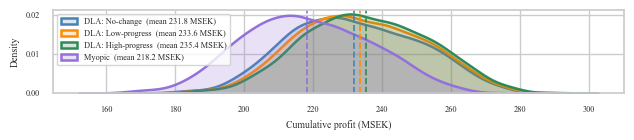

In [24]:
fig, ax = plt.subplots(figsize=(6.48, 1.5))  # For latex
# fig, ax = plt.subplots(figsize=(10, 5))

for name, records in all_records.items():
    profits = np.array([r.total_reward for r in records]) / 1e6  # MSEK
    sns.kdeplot(
        profits,
        ax=ax,
        label=f"{name}  (mean {profits.mean():.1f} MSEK)",
        color=PALETTE[name],
        linewidth=1.8,
        fill=True,
        alpha=0.20,
    )
    ax.axvline(
        profits.mean(),
        color=PALETTE[name],
        linewidth=1.2,
        linestyle="--",
    )

ax.set_xlabel("Cumulative profit (MSEK)")
ax.set_ylabel("Density")
# ax.set_title("Distribution of cumulative profit across episodes")
ax.legend()  # loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=2)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "cumulative_profit.pgf", backend="pgf")
plt.show()

C:\Users\SIFR\AppData\Local\Temp\ipykernel_26928\2001491211.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


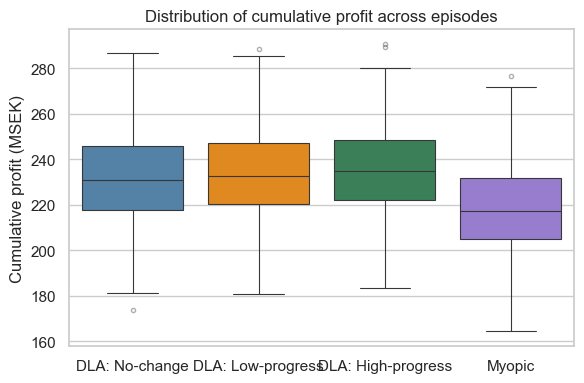

In [4]:
# Build long-form DataFrame: one row per episode
profit_df = pd.DataFrame(
    [
        {"Experiment": name, "Cumulative profit (MSEK)": r.total_reward / 1e6}
        for name, records in all_records.items()
        for r in records
    ]
)

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=profit_df,
    x="Experiment",
    y="Cumulative profit (MSEK)",
    ax=ax,
    palette=PALETTE,
    linewidth=0.8,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    order=list(EXPERIMENTS.keys()),
)

ax.set_xlabel("")
ax.set_ylabel("Cumulative profit (MSEK)")
ax.set_title("Distribution of cumulative profit across episodes")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "compare_fig1_cumulative_profit_box.pgf", backend="pgf")
plt.show()

## 4 — BET fleet share — one subplot per experiment

Each subplot mirrors the style in `analyse_batch.ipynb`.


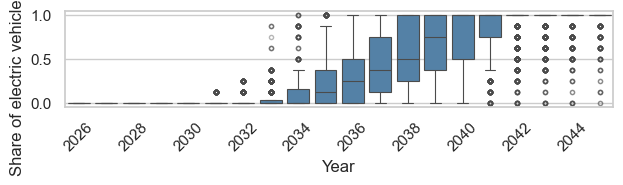

Saved: bet_share_dla: no-change.pgf


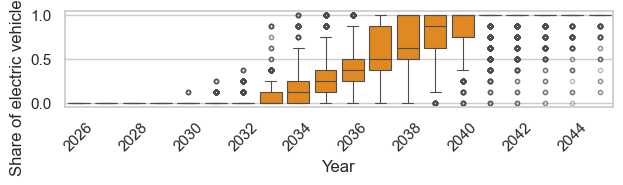

Saved: bet_share_dla: low-progress.pgf


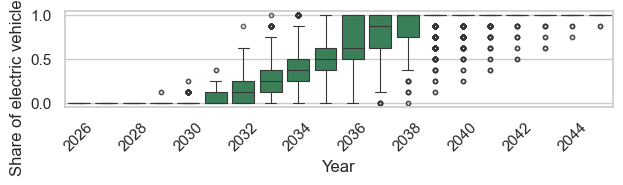

Saved: bet_share_dla: high-progress.pgf


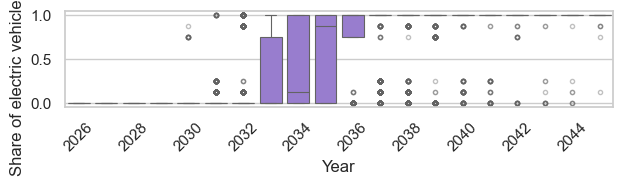

Saved: bet_share_myopic.pgf


In [5]:
for name, records in all_records.items():
    fleet_size = records[0].fleet_size
    years = records[0].years

    df = pd.DataFrame(
        [
            {"year": year, "BET share": n_elec / fleet_size}
            for r in records
            for year, n_elec in zip(r.years, r.n_electric)
        ]
    )

    fig, ax = plt.subplots(figsize=(6.48 * 3 / 3, 2.0))

    sns.boxplot(
        data=df,
        x="year",
        y="BET share",
        ax=ax,
        color=PALETTE[name],
        linewidth=0.8,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )

    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of electric vehicles (BET)")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticks(ax.get_xticks()[::2])

    plt.tight_layout()
    filename = f"bet_share_{name.lower()}.pgf"
    fig.savefig(FIGURES_DIR / filename, backend="pgf", bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")

## 5 — BET fleet share — combined figure

Three side-by-side boxes at each timestep, one colour per experiment.


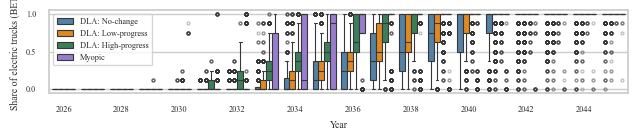

In [34]:
# Build a combined long-form DataFrame with an "Experiment" column
frames = []
for name, records in all_records.items():
    fleet_size = records[0].fleet_size
    df = pd.DataFrame(
        [
            {"year": year, "BET share": n_elec / fleet_size, "Experiment": name}
            for r in records
            for year, n_elec in zip(r.years, r.n_electric)
        ]
    )
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)
# combined = combined.loc[combined["Experiment"] == "DLA: No-change"]

fig, ax = plt.subplots(figsize=(6.48, 1.5))
# fig, ax = plt.subplots(figsize=(6.48 * 2, 3 * 2))

sns.boxplot(
    data=combined,
    x="year",
    y="BET share",
    hue="Experiment",
    ax=ax,
    palette=PALETTE,
    linewidth=0.8,
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Year")
ax.set_ylabel("Share of electric trucks (BET)")
# ax.set_title("BET fleet share per year — all experiments")
# ax.tick_params(axis="x", rotation=45)
ax.set_xticks(ax.get_xticks()[::2])
# ax.legend(title="Experiment", loc="upper left")
ax.legend()  # Hide legend for LaTeX version

plt.tight_layout()
# fig.savefig(FIGURES_DIR / "bet_share_combined.pgf", backend="pgf")
fig.savefig(FIGURES_DIR / "bet_share_combined.pdf")  # , backend="pgf")
plt.show()

In [28]:
combined.loc[combined["Experiment"] == "DLA: No-change"]

,year,BET share,Experiment
0,2026,0.0,DLA: No-change
1,2027,0.0,DLA: No-change
2,2028,0.0,DLA: No-change
3,2029,0.0,DLA: No-change
4,2030,0.0,DLA: No-change
...,...,...,...
39995,2041,1.0,DLA: No-change
39996,2042,1.0,DLA: No-change
39997,2043,1.0,DLA: No-change
39998,2044,1.0,DLA: No-change


## 6 — Exogenous process trajectories (sanity check)

Overlay the median trajectory and 10–90 % band for each experiment.  
If the scenarios were drawn from the same distributions the bands should be statistically indistinguishable.


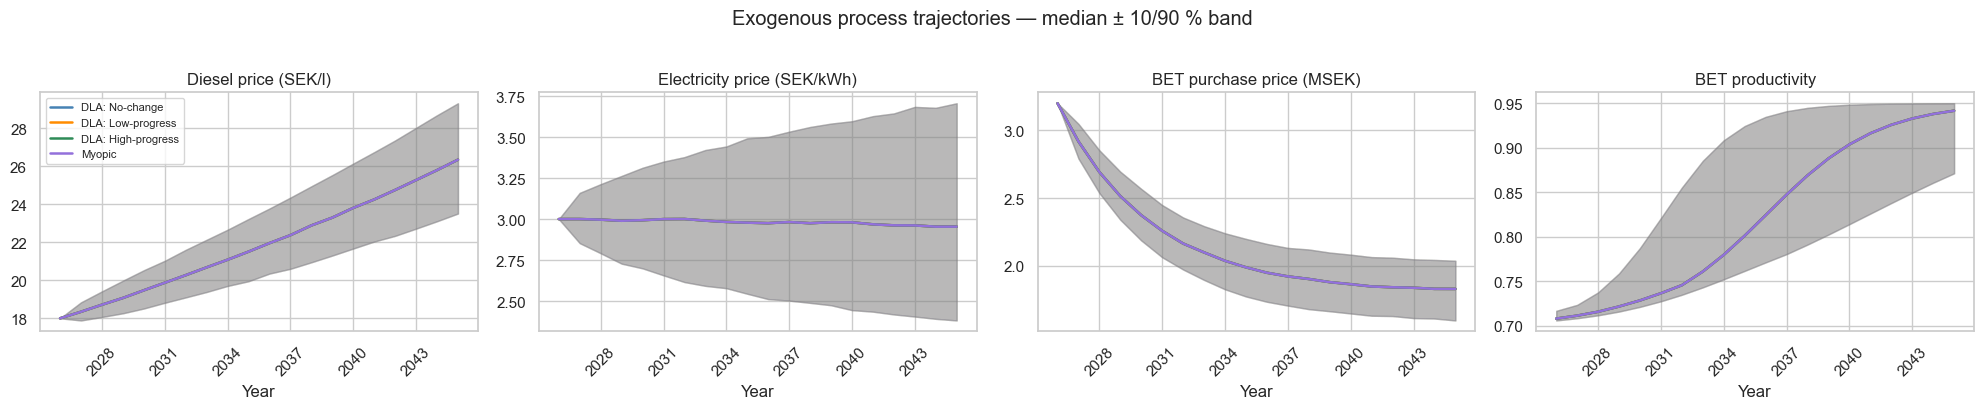

In [7]:
from matplotlib.ticker import MaxNLocator

_VARIABLES = [
    ("Diesel price (SEK/l)", lambda r: r.energy_prices_diesel),
    ("Electricity price (SEK/kWh)", lambda r: r.energy_prices_electricity),
    ("BET purchase price (MSEK)", lambda r: r.purchase_prices_BET / 1e6),
    ("BET productivity", lambda r: r.productivities_BET),
]

n_cols = len(_VARIABLES)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=False)

for ax, (var_label, accessor) in zip(axes, _VARIABLES):
    for name, records in all_records.items():
        years = records[0].years
        mat = np.stack([accessor(r) for r in records])  # (n_episodes, n_steps)
        p10 = np.percentile(mat, 10, axis=0)
        p50 = np.percentile(mat, 50, axis=0)
        p90 = np.percentile(mat, 90, axis=0)

        color = PALETTE[name]
        ax.fill_between(years, p10, p90, color=color, alpha=0.18)
        ax.plot(years, p50, color=color, linewidth=1.8, label=name)

    ax.set_title(var_label)
    ax.set_xlabel("Year")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", rotation=45)

axes[0].legend(fontsize=8)
fig.suptitle("Exogenous process trajectories — median ± 10/90 % band", y=1.02)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / "compare_fig3_info_state.pgf", backend="pgf")
plt.show()

## 7 — Top-15 % episodes: which exogenous scenarios are most profitable?

For each experiment, identify the top 15 % episodes by cumulative profit and
compare the full info-state trajectories of those high-profit episodes against
the rest. Four variables are shown: diesel price, electricity price, BET
purchase price, and BET productivity.

- **Coloured band / line** — top-15 % group (median ± IQR)
- **Grey band / line** — bottom-85 % group (median ± IQR)

A variable that consistently differs between the two groups is a strong driver
of profitability in that scenario.


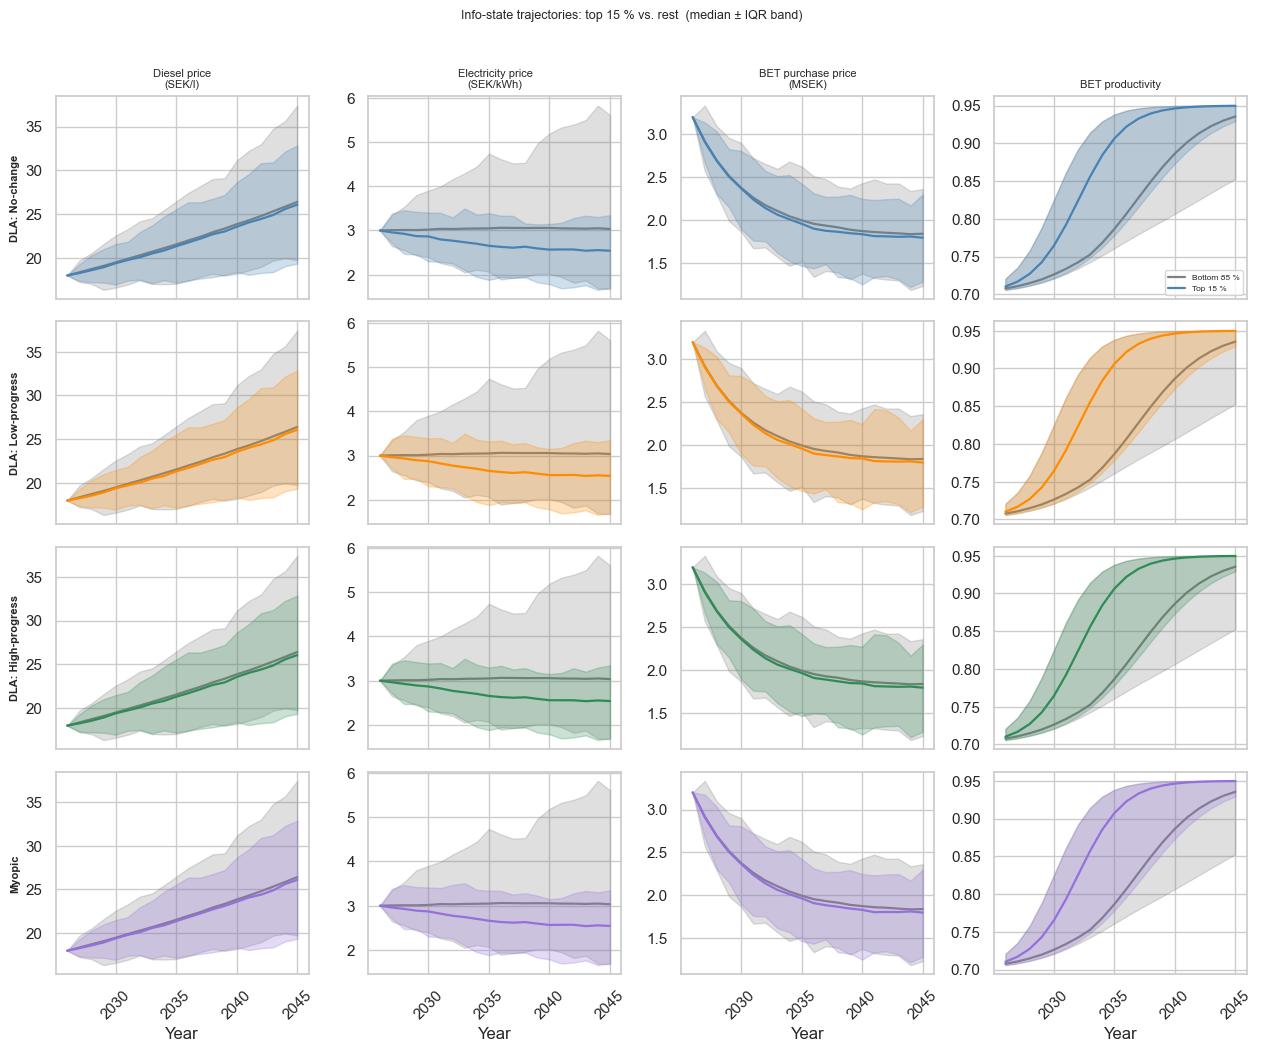

Top-15 % profit threshold per experiment:
  DLA: No-change : >= 253.0 MSEK  (300 episodes)
  DLA: Low-progress: >= 254.2 MSEK  (300 episodes)
  DLA: High-progress: >= 255.5 MSEK  (300 episodes)
  Myopic         : >= 238.7 MSEK  (300 episodes)


In [8]:
from matplotlib.ticker import MaxNLocator

TOP_FRAC = 0.15  # fraction of episodes to label "top"

_INFO_VARS = [
    ("Diesel price\n(SEK/l)", lambda r: r.energy_prices_diesel),
    ("Electricity price\n(SEK/kWh)", lambda r: r.energy_prices_electricity),
    ("BET purchase price\n(MSEK)", lambda r: r.purchase_prices_BET / 1e6),
    ("BET productivity", lambda r: r.productivities_BET),
]

n_rows = len(EXPERIMENTS)
n_cols = len(_INFO_VARS)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.2 * n_cols, 2.6 * n_rows),
    sharey="col",
    sharex="col",
)

for row_idx, (exp_name, records) in enumerate(all_records.items()):
    years = records[0].years
    color = PALETTE[exp_name]

    # Split into top-15 % and rest by cumulative profit
    profits = np.array([r.total_reward for r in records])
    threshold = np.quantile(profits, 1 - TOP_FRAC)
    top_mask = profits >= threshold

    top_records = [r for r, m in zip(records, top_mask) if m]
    rest_records = [r for r, m in zip(records, top_mask) if not m]

    for col_idx, (var_label, accessor) in enumerate(_INFO_VARS):
        ax = axes[row_idx, col_idx]

        for group_records, group_color, group_label, zorder in [
            (rest_records, "grey", f"Bottom {int((1 - TOP_FRAC) * 100)} %", 1),
            (top_records, color, f"Top {int(TOP_FRAC * 100)} %", 2),
        ]:
            mat = np.stack([accessor(r) for r in group_records])
            p0 = np.percentile(mat, 0, axis=0)
            p50 = np.percentile(mat, 50, axis=0)
            p100 = np.percentile(mat, 100, axis=0)
            ax.fill_between(
                years, p0, p100, color=group_color, alpha=0.25, zorder=zorder
            )
            ax.plot(
                years,
                p50,
                color=group_color,
                linewidth=1.6,
                label=group_label,
                zorder=zorder,
            )

        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        ax.tick_params(axis="x", rotation=45)

        if col_idx == 0:
            ax.set_ylabel(exp_name, fontsize=8, fontweight="bold")
        if row_idx == 0:
            ax.set_title(var_label, fontsize=8)
        if row_idx == n_rows - 1:
            ax.set_xlabel("Year")
        if row_idx == 0 and col_idx == n_cols - 1:
            ax.legend(fontsize=6, loc="lower right")

fig.suptitle(
    f"Info-state trajectories: top {int(TOP_FRAC * 100)} % vs. rest  "
    f"(median ± IQR band)",
    y=1.01,
    fontsize=9,
)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / "top_episodes_info_state.pgf", backend="pgf", bbox_inches="tight")
plt.show()

print(f"Top-{int(TOP_FRAC * 100)} % profit threshold per experiment:")
for exp_name, records in all_records.items():
    profits = np.array([r.total_reward for r in records])
    threshold = np.quantile(profits, 1 - TOP_FRAC)
    n_top = int(np.sum(profits >= threshold))
    print(f"  {exp_name:15s}: >= {threshold / 1e6:.1f} MSEK  ({n_top} episodes)")

## 8 — Top / middle / bottom 15 % episodes

Same layout as section 7, but split into three groups: the top 15 %, the middle 70 %, and the bottom 15 % by cumulative profit. This lets you see whether the middle group tracks closer to the top or the bottom for each market variable.

- **Coloured solid line / band** — top 15 %
- **Grey solid line / band** — middle 70 %
- **Tomato dashed line / band** — bottom 15 %


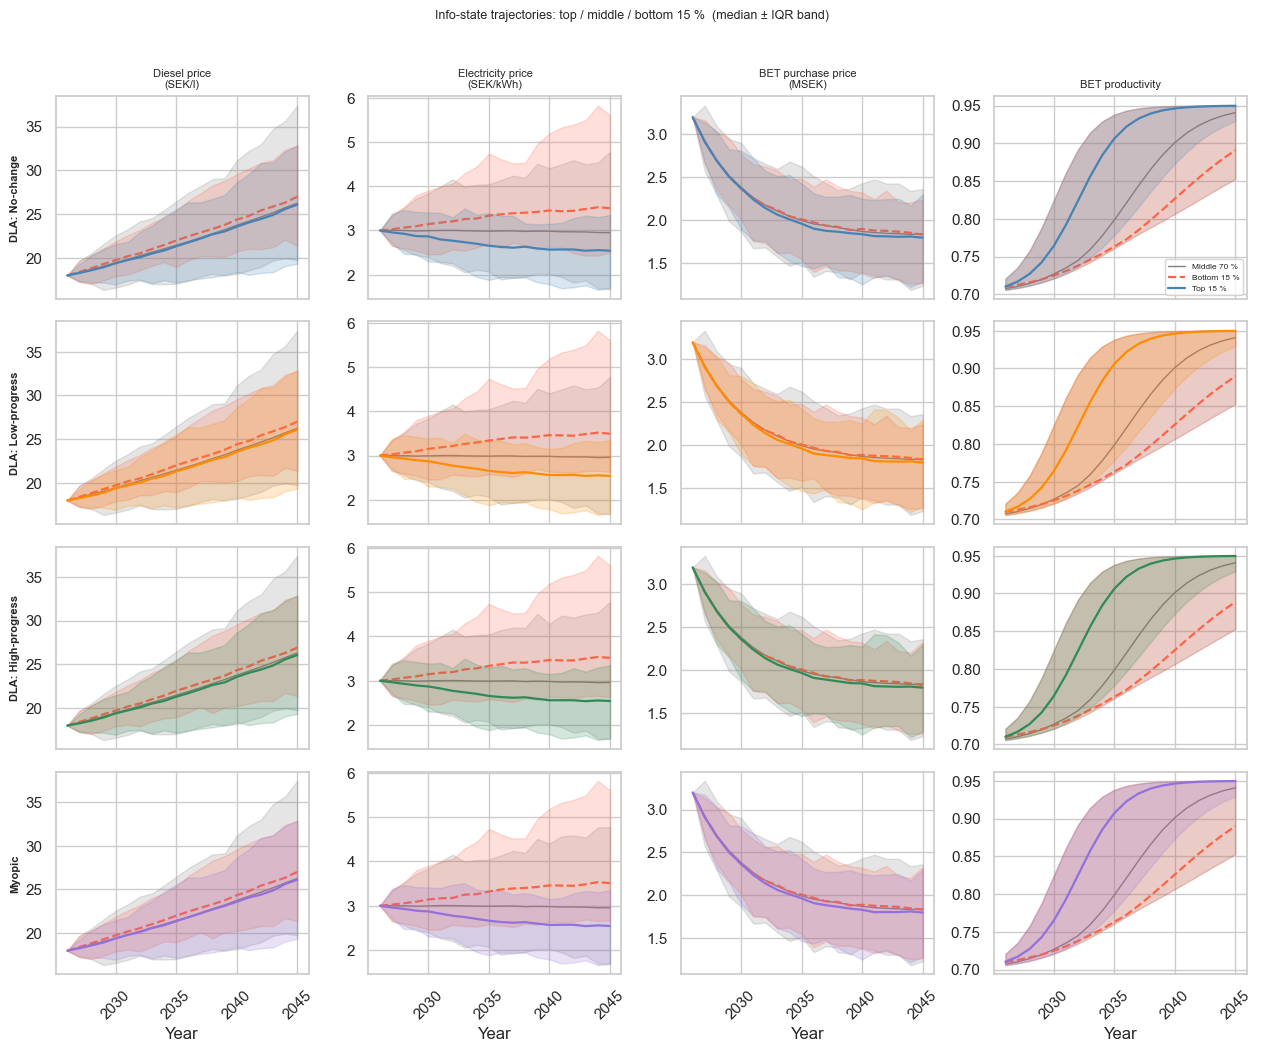

Group sizes per experiment (top / middle / bottom 15 %):
  DLA: No-change : top >= 253.0 MSEK (300)  |  middle (1400)  |  bottom <= 212.3 MSEK (300)
  DLA: Low-progress: top >= 254.2 MSEK (300)  |  middle (1400)  |  bottom <= 214.1 MSEK (300)
  DLA: High-progress: top >= 255.5 MSEK (300)  |  middle (1400)  |  bottom <= 216.5 MSEK (300)
  Myopic         : top >= 238.7 MSEK (300)  |  middle (1400)  |  bottom <= 198.6 MSEK (300)


In [9]:
TAIL_FRAC = 0.15  # symmetric tail fraction

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.2 * n_cols, 2.6 * n_rows),
    sharey="col",
    sharex="col",
)

for row_idx, (exp_name, records) in enumerate(all_records.items()):
    years = records[0].years
    color = PALETTE[exp_name]

    profits = np.array([r.total_reward for r in records])
    top_threshold = np.quantile(profits, 1 - TAIL_FRAC)
    bot_threshold = np.quantile(profits, TAIL_FRAC)

    top_ep = [r for r, p in zip(records, profits) if p >= top_threshold]
    bot_ep = [r for r, p in zip(records, profits) if p <= bot_threshold]
    mid_ep = [r for r, p in zip(records, profits) if bot_threshold < p < top_threshold]

    for col_idx, (var_label, accessor) in enumerate(_INFO_VARS):
        ax = axes[row_idx, col_idx]

        for group_records, group_color, group_label, ls, lw, zorder in [
            (mid_ep, "grey", f"Middle {int((1 - 2 * TAIL_FRAC) * 100)} %", "-", 1.0, 1),
            (bot_ep, "tomato", f"Bottom {int(TAIL_FRAC * 100)} %", "--", 1.6, 2),
            (top_ep, color, f"Top {int(TAIL_FRAC * 100)} %", "-", 1.6, 3),
        ]:
            mat = np.stack([accessor(r) for r in group_records])
            p0 = np.percentile(mat, 0, axis=0)
            p50 = np.percentile(mat, 50, axis=0)
            p100 = np.percentile(mat, 100, axis=0)
            ax.fill_between(
                years, p0, p100, color=group_color, alpha=0.20, zorder=zorder
            )
            ax.plot(
                years,
                p50,
                color=group_color,
                linewidth=lw,
                linestyle=ls,
                label=group_label,
                zorder=zorder,
            )

        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        ax.tick_params(axis="x", rotation=45)

        if col_idx == 0:
            ax.set_ylabel(exp_name, fontsize=8, fontweight="bold")
        if row_idx == 0:
            ax.set_title(var_label, fontsize=8)
        if row_idx == n_rows - 1:
            ax.set_xlabel("Year")
        if row_idx == 0 and col_idx == n_cols - 1:
            ax.legend(fontsize=6, loc="lower right")

fig.suptitle(
    f"Info-state trajectories: top / middle / bottom {int(TAIL_FRAC * 100)} %  "
    f"(median \u00b1 IQR band)",
    y=1.01,
    fontsize=9,
)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / "top_vs_bottom_episodes_info_state.pgf", backend="pgf", bbox_inches="tight")
plt.show()

print(f"Group sizes per experiment (top / middle / bottom {int(TAIL_FRAC * 100)} %):")
for exp_name, records in all_records.items():
    profits = np.array([r.total_reward for r in records])
    top_thr = np.quantile(profits, 1 - TAIL_FRAC)
    bot_thr = np.quantile(profits, TAIL_FRAC)
    n_top = int(np.sum(profits >= top_thr))
    n_bot = int(np.sum(profits <= bot_thr))
    n_mid = len(records) - n_top - n_bot
    print(
        f"  {exp_name:15s}: top >= {top_thr / 1e6:.1f} MSEK ({n_top})  |  "
        f"middle ({n_mid})  |  "
        f"bottom <= {bot_thr / 1e6:.1f} MSEK ({n_bot})"
    )

## 9 — Top-15 % across experiments: which scenario assumption leads to the best outcomes?

Four subplots, one per market variable. Each subplot overlays the top-15 % episodes from all three experiments. This directly answers the question: _under which agent forecast assumption do the best-case exogenous scenarios look different?_

- Each experiment's top-15 % episodes are shown in that experiment's colour (median ± IQR band).


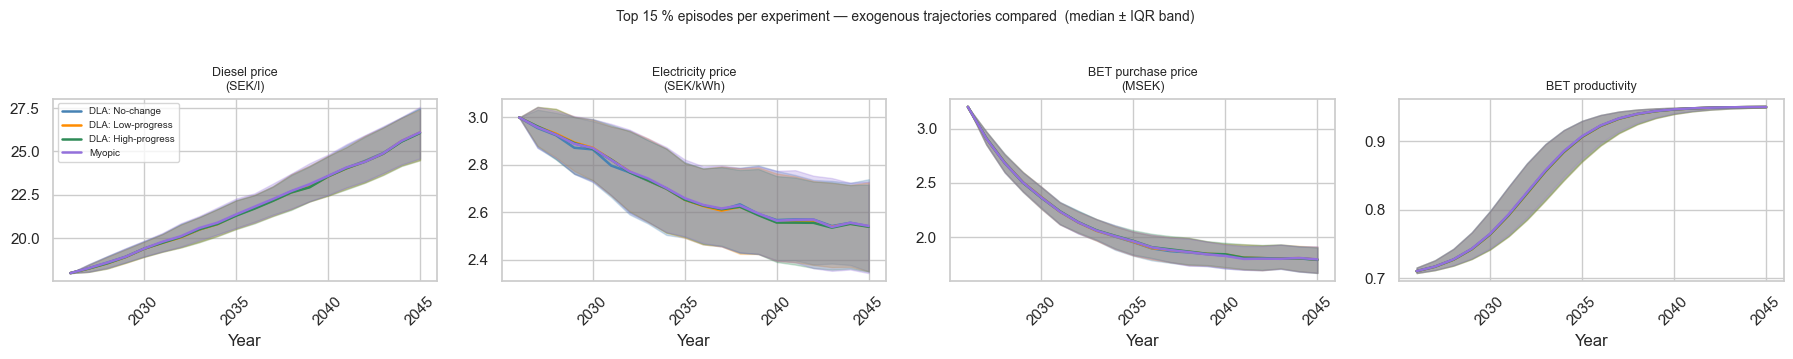

In [10]:
TOP_FRAC_CROSS = 0.15  # fraction to select as "top" within each experiment

fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 3.5), sharey=False)

for col_idx, (var_label, accessor) in enumerate(_INFO_VARS):
    ax = axes[col_idx]

    for exp_name, records in all_records.items():
        years = records[0].years
        color = PALETTE[exp_name]

        profits = np.array([r.total_reward for r in records])
        top_threshold = np.quantile(profits, 1 - TOP_FRAC_CROSS)
        top_ep = [r for r, p in zip(records, profits) if p >= top_threshold]

        mat = np.stack([accessor(r) for r in top_ep])
        p25 = np.percentile(mat, 25, axis=0)
        p50 = np.percentile(mat, 50, axis=0)
        p75 = np.percentile(mat, 75, axis=0)

        ax.fill_between(years, p25, p75, color=color, alpha=0.25)
        ax.plot(years, p50, color=color, linewidth=1.8, label=exp_name)

    ax.set_title(var_label, fontsize=9)
    ax.set_xlabel("Year")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.tick_params(axis="x", rotation=45)
    if col_idx == 0:
        ax.legend(fontsize=7)

fig.suptitle(
    f"Top {int(TOP_FRAC_CROSS * 100)} % episodes per experiment — exogenous trajectories compared  "
    f"(median \u00b1 IQR band)",
    y=1.02,
    fontsize=10,
)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / "top_cross_experiment_info_state.pgf", backend="pgf", bbox_inches="tight")
plt.show()

## 10 — Fast vs slow electrification episodes (>= 80 % BET share)

This section groups episodes by how quickly they reach at least 80 % BET fleet share.

- **Fast**: the earliest 15 % of episodes that reach >= 80 %.
- **Slow**: all remaining episodes, including episodes that never reach >= 80 %.

The figure keeps the same structure as earlier analyses: one row per experiment and one column per exogenous variable. In each subplot, coloured curves/bands show the fast group, while grey shows the slow group (median with full-range band).

A summary table is printed after plotting with group sizes, never-reached counts, and median reach year for fast vs slow.


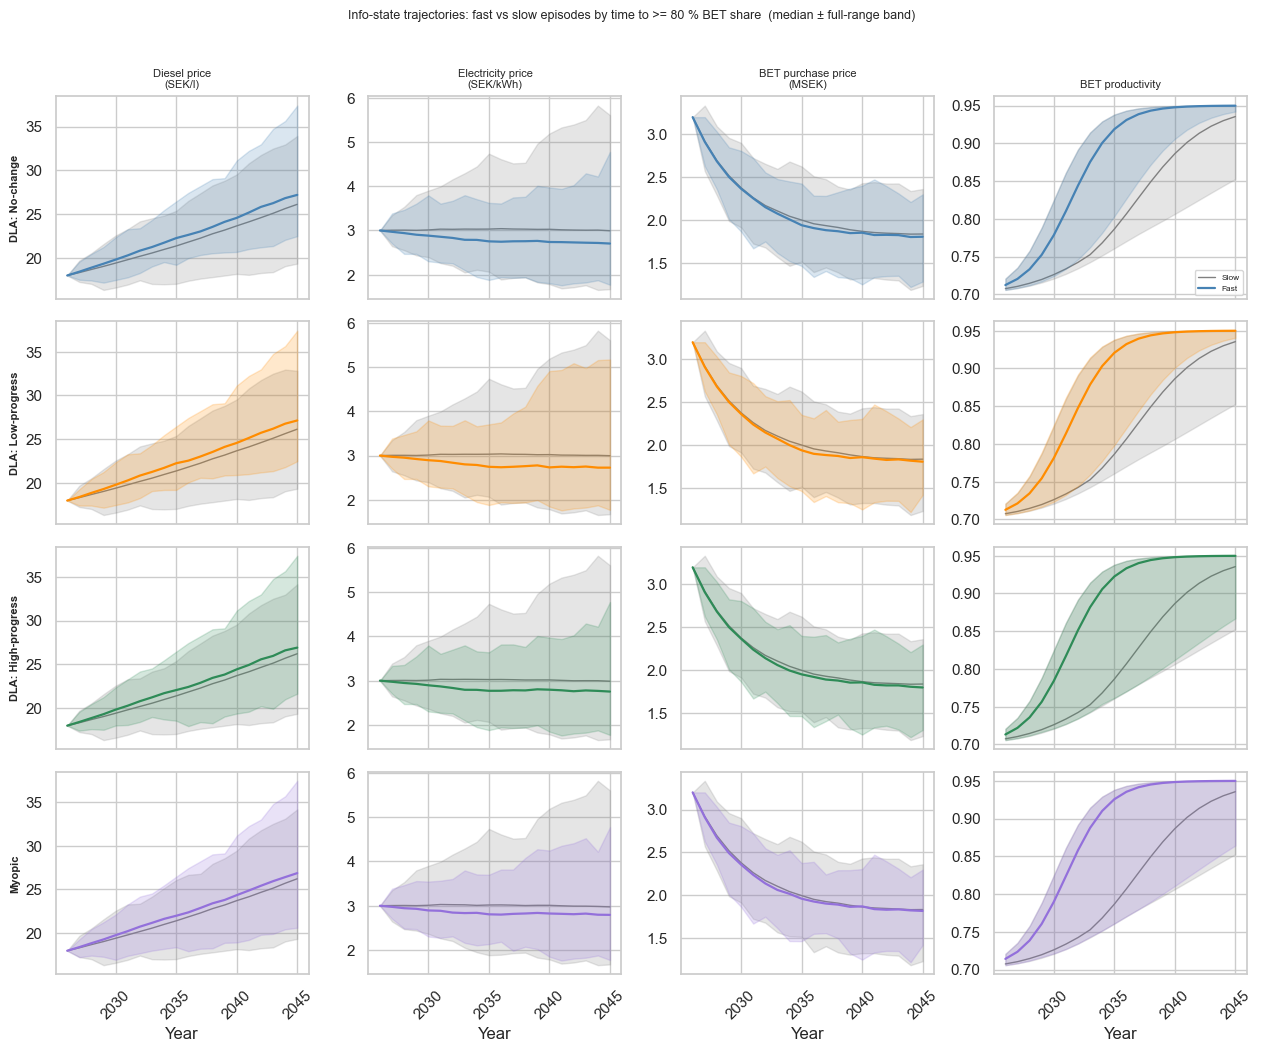

Group sizes per experiment (fastest 15 % by year reaching >= 80 % BET share):
  DLA: No-change : fast (300) | slow (1700) | never reached (63) | median year fast/slow: 2036/2040
  DLA: Low-progress: fast (300) | slow (1700) | never reached (22) | median year fast/slow: 2035/2039
  DLA: High-progress: fast (300) | slow (1700) | never reached (0) | median year fast/slow: 2034/2038
  Myopic         : fast (300) | slow (1700) | never reached (2) | median year fast/slow: 2032/2036


In [11]:
FAST_FRAC = 0.15  # fastest share to classify as "fast"
EV_TARGET = 0.80  # target BET share threshold


def first_year_reaching_ev_target(record, target=EV_TARGET):
    """Return first year where BET share >= target, or np.inf if never reached."""
    share = np.asarray(record.n_electric, dtype=float) / float(record.fleet_size)
    idx = np.where(share >= target)[0]
    if idx.size == 0:
        return np.inf
    return float(record.years[idx[0]])


fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.2 * n_cols, 2.6 * n_rows),
    sharey="col",
    sharex="col",
)

# Keep indexing stable when there is only one experiment row.
if n_rows == 1:
    axes = np.array([axes])

for row_idx, (exp_name, records) in enumerate(all_records.items()):
    years = records[0].years
    color = PALETTE[exp_name]

    reach_year = np.array(
        [first_year_reaching_ev_target(r) for r in records], dtype=float
    )
    reached_mask = np.isfinite(reach_year)
    reached_idx = np.where(reached_mask)[0]

    # Select fast among episodes that do reach the target; never-reached are always slow.
    if reached_idx.size > 0:
        n_fast = max(1, int(np.ceil(FAST_FRAC * len(records))))
        n_fast = min(n_fast, reached_idx.size)
        reached_sorted = reached_idx[np.argsort(reach_year[reached_idx], kind="stable")]
        fast_idx = set(reached_sorted[:n_fast].tolist())
    else:
        fast_idx = set()

    fast_ep = [r for i, r in enumerate(records) if i in fast_idx]
    slow_ep = [r for i, r in enumerate(records) if i not in fast_idx]

    for col_idx, (var_label, accessor) in enumerate(_INFO_VARS):
        ax = axes[row_idx, col_idx]

        for group_records, group_color, group_label, ls, lw, zorder in [
            (slow_ep, "grey", "Slow", "-", 1.0, 1),
            (fast_ep, color, "Fast", "-", 1.6, 2),
        ]:
            if len(group_records) == 0:
                continue
            mat = np.stack([accessor(r) for r in group_records])
            p0 = np.percentile(mat, 0, axis=0)
            p50 = np.percentile(mat, 50, axis=0)
            p100 = np.percentile(mat, 100, axis=0)
            ax.fill_between(
                years, p0, p100, color=group_color, alpha=0.20, zorder=zorder
            )
            ax.plot(
                years,
                p50,
                color=group_color,
                linewidth=lw,
                linestyle=ls,
                label=group_label,
                zorder=zorder,
            )

        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        ax.tick_params(axis="x", rotation=45)

        if col_idx == 0:
            ax.set_ylabel(exp_name, fontsize=8, fontweight="bold")
        if row_idx == 0:
            ax.set_title(var_label, fontsize=8)
        if row_idx == n_rows - 1:
            ax.set_xlabel("Year")
        if row_idx == 0 and col_idx == n_cols - 1:
            ax.legend(fontsize=6, loc="lower right")

fig.suptitle(
    f"Info-state trajectories: fast vs slow episodes by time to >= {int(EV_TARGET * 100)} % BET share  "
    f"(median ± full-range band)",
    y=1.01,
    fontsize=9,
)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / "fast_vs_slow_80pct_bet_info_state.pgf", backend="pgf", bbox_inches="tight")
plt.show()

print(
    f"Group sizes per experiment (fastest {int(FAST_FRAC * 100)} % by year reaching >= {int(EV_TARGET * 100)} % BET share):"
)
for exp_name, records in all_records.items():
    reach_year = np.array(
        [first_year_reaching_ev_target(r) for r in records], dtype=float
    )
    reached_mask = np.isfinite(reach_year)
    reached_idx = np.where(reached_mask)[0]

    if reached_idx.size > 0:
        n_fast = max(1, int(np.ceil(FAST_FRAC * len(records))))
        n_fast = min(n_fast, reached_idx.size)
        reached_sorted = reached_idx[np.argsort(reach_year[reached_idx], kind="stable")]
        fast_set = set(reached_sorted[:n_fast].tolist())
    else:
        fast_set = set()

    n_fast = len(fast_set)
    n_slow = len(records) - n_fast
    n_never = int(np.sum(~reached_mask))

    fast_years = reach_year[list(fast_set)] if n_fast > 0 else np.array([])
    slow_years = np.array(
        [y for i, y in enumerate(reach_year) if i not in fast_set and np.isfinite(y)]
    )

    fast_med = f"{np.median(fast_years):.0f}" if fast_years.size > 0 else "NA"
    slow_med = f"{np.median(slow_years):.0f}" if slow_years.size > 0 else "NA"

    print(
        f"  {exp_name:15s}: fast ({n_fast}) | slow ({n_slow}) | "
        f"never reached ({n_never}) | median year fast/slow: {fast_med}/{slow_med}"
    )

## 11 — Overlap: profitability vs fast electrification

Compares the top 15 % most profitable episodes against the fastest 15 % to reach >= 80 % BET share.

This analysis answers: Are high-profit episodes the same as fast-electrifying episodes, or are they driven by different factors?

- **Both**: episodes in both top-profit and fastest-electrification groups.
- **Profit only**: top-profit but not fastest-electrifying.
- **Fast only**: fastest-electrifying but not top-profit.
- **Overlap %**: percentage of fastest episodes that are also highly profitable.


OVERLAP ANALYSIS: Top 15% Profitable vs Fastest 15% to >=80% BET Share

DLA: No-change:
  Top 15% profitable:     300 episodes
  Fastest 15% (>=80%):    300 episodes
  Both (overlap):         179 episodes (59.7% of fastest)
  Profit only:            121 episodes
  Fast only:              121 episodes
  Neither:                1579 episodes

DLA: Low-progress:
  Top 15% profitable:     300 episodes
  Fastest 15% (>=80%):    300 episodes
  Both (overlap):         168 episodes (56.0% of fastest)
  Profit only:            132 episodes
  Fast only:              132 episodes
  Neither:                1568 episodes

DLA: High-progress:
  Top 15% profitable:     300 episodes
  Fastest 15% (>=80%):    300 episodes
  Both (overlap):         165 episodes (55.0% of fastest)
  Profit only:            135 episodes
  Fast only:              135 episodes
  Neither:                1565 episodes

Myopic:
  Top 15% profitable:     300 episodes
  Fastest 15% (>=80%):    300 episodes
  Both (overlap):     

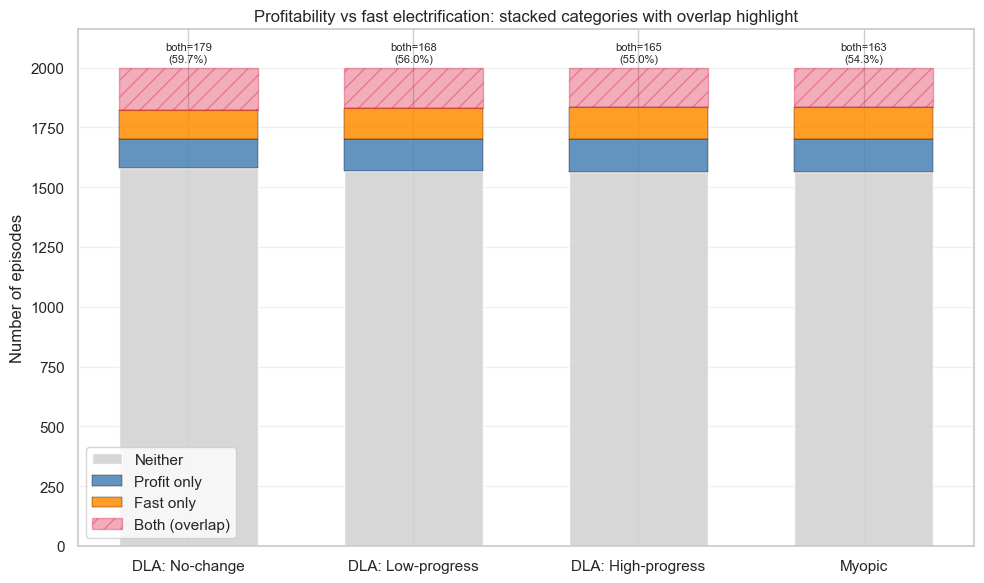

In [12]:
# Compute overlap between top 15% profitable and fastest 15% to >=80% BET share
OVERLAP_FRAC = 0.15

print("=" * 80)
print("OVERLAP ANALYSIS: Top 15% Profitable vs Fastest 15% to >=80% BET Share")
print("=" * 80)
print()

overlap_data = {}

for exp_name, records in all_records.items():
    # Identify top 15% by profit
    profits = np.array([r.total_reward for r in records])
    profit_threshold = np.quantile(profits, 1 - OVERLAP_FRAC)
    top_profit_idx = set(np.where(profits >= profit_threshold)[0].tolist())

    # Identify fastest 15% to reach >=80% BET share
    reach_year = np.array(
        [first_year_reaching_ev_target(r) for r in records], dtype=float
    )
    reached_mask = np.isfinite(reach_year)
    reached_idx = np.where(reached_mask)[0]

    if reached_idx.size > 0:
        n_fast = max(1, int(np.ceil(OVERLAP_FRAC * len(records))))
        n_fast = min(n_fast, reached_idx.size)
        reached_sorted = reached_idx[np.argsort(reach_year[reached_idx], kind="stable")]
        fast_electrify_idx = set(reached_sorted[:n_fast].tolist())
    else:
        fast_electrify_idx = set()

    # Disjoint overlap partition
    both = top_profit_idx & fast_electrify_idx
    profit_only = top_profit_idx - fast_electrify_idx
    fast_only = fast_electrify_idx - top_profit_idx
    neither = set(range(len(records))) - (top_profit_idx | fast_electrify_idx)

    n_both = len(both)
    n_profit_only = len(profit_only)
    n_fast_only = len(fast_only)
    n_neither = len(neither)
    n_total = len(records)

    # Integrity check: categories must partition all episodes exactly once
    if n_both + n_profit_only + n_fast_only + n_neither != n_total:
        raise ValueError(
            f"Partition mismatch for {exp_name}: "
            f"both={n_both}, profit_only={n_profit_only}, "
            f"fast_only={n_fast_only}, neither={n_neither}, total={n_total}"
        )

    overlap_pct = (
        (n_both / len(fast_electrify_idx) * 100) if len(fast_electrify_idx) > 0 else 0.0
    )

    overlap_data[exp_name] = {
        "both": n_both,
        "profit_only": n_profit_only,
        "fast_only": n_fast_only,
        "neither": n_neither,
        "total": n_total,
        "overlap_pct": overlap_pct,
        "n_profit": len(top_profit_idx),
        "n_fast": len(fast_electrify_idx),
    }

    print(f"{exp_name}:")
    print(f"  Top 15% profitable:     {len(top_profit_idx)} episodes")
    print(f"  Fastest 15% (>=80%):    {len(fast_electrify_idx)} episodes")
    print(
        f"  Both (overlap):         {n_both} episodes ({overlap_pct:.1f}% of fastest)"
    )
    print(f"  Profit only:            {n_profit_only} episodes")
    print(f"  Fast only:              {n_fast_only} episodes")
    print(f"  Neither:                {n_neither} episodes")
    print()

# Create stacked chart with transparent overlap layer
fig, ax = plt.subplots(figsize=(10, 6))

exp_names = list(overlap_data.keys())
neither_counts = np.array([overlap_data[name]["neither"] for name in exp_names])
profit_only_counts = np.array([overlap_data[name]["profit_only"] for name in exp_names])
fast_only_counts = np.array([overlap_data[name]["fast_only"] for name in exp_names])
both_counts = np.array([overlap_data[name]["both"] for name in exp_names])
totals = np.array([overlap_data[name]["total"] for name in exp_names])
overlap_pcts = [overlap_data[name]["overlap_pct"] for name in exp_names]

x = np.arange(len(exp_names))
width = 0.62

# Base stack uses disjoint categories only
ax.bar(x, neither_counts, width, label="Neither", color="lightgrey", alpha=0.9)
ax.bar(
    x,
    profit_only_counts,
    width,
    bottom=neither_counts,
    label="Profit only",
    color="steelblue",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.3,
    zorder=2,
)
ax.bar(
    x,
    fast_only_counts,
    width,
    bottom=neither_counts + profit_only_counts,
    label="Fast only",
    color="darkorange",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.3,
    zorder=2,
)

# Transparent overlap highlight on top
ax.bar(
    x,
    both_counts,
    width,
    bottom=neither_counts + profit_only_counts + fast_only_counts,
    label="Both (overlap)",
    color="crimson",
    alpha=0.35,
    edgecolor="crimson",
    linewidth=1.0,
    hatch="//",
    zorder=3,
)

for i, (total, both, pct) in enumerate(zip(totals, both_counts, overlap_pcts)):
    ax.text(
        x[i],
        total + max(8, 0.008 * total),
        f"both={both}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_ylabel("Number of episodes")
ax.set_title(
    "Profitability vs fast electrification: stacked categories with overlap highlight"
)
ax.set_xticks(x)
ax.set_xticklabels(exp_names)
ax.set_ylim(0, max(totals) * 1.08)
ax.legend()  # loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()